In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import root_mean_squared_error as rmse
import time
import tkinter as tk
from tkinter import messagebox
import math
import matplotlib as mpl
from scipy.spatial import ConvexHull
import os
# our functions
import predict_Beta_I
import choice_start_day
import plot_hyb

import warnings
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

## !

In [5]:
def apply_methods(seed_dirs='initial_data/initial_data_ba_10000/',
                  seed_numbers=[], on_incidence=False, 
                 idx_s=0, idx_e=11, show_fig_flag=False,
                 is_filename=False, sigma=0.1, gamma=0.08, perc_switch=0.01,
                 suff_m='sw100k', suff='sw100k'):
    
    #df_seeds = pd.read_csv(df_seeds)
    if is_filename:
        col = 'file'
    else:
        col='seed_number'
        
    #seed_numbers = df_seeds[df_seeds.set=='test'][col].values[:n_seeds]

    types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']

    methods = ['last value','expanding mean last value',
               'median beta', 
               #'regression (day)',
               'regression beta', #'arimax',
               'lstm'
              ]

    new_labels = ['last_value', 'expanding_mean_last_value', 

            'median_beta', #'regression_day',
            'regression_beta', #'arimax',
                  'lstm_day_E_previous_I'
                 ]

    for type_start_day in types_start_day:

        for beta_pred,new_label in zip(methods[idx_s:idx_e], 
                                       new_labels[idx_s:idx_e]):

            if 'median' in beta_pred:
                model_path = f'{suff_m}_median_beta.csv'
            elif 'regression beta' in  beta_pred:
                model_path = f'{suff_m}_regression_bt.joblib'
            elif 'lstm' in beta_pred:
                model_path = f'{suff_m}_lstm_4_001_s10'   
            else:
                model_path=''
            print('path: ', model_path)
            
            try:
                all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
                    all_r2, all_r2_Inc, all_peak, \
                    execution_time, start_days = plot_hyb.main_f(I_prediction_method='seir', 
                                        stochastic=False, count_stoch_line=0, 
                                        beta_prediction_method=beta_pred, 
                                        type_start_day=type_start_day, 
                                        seed_numbers=seed_numbers, 
                                        show_fig_flag=show_fig_flag,
                                        seed_dirs=seed_dirs, 
                                        sigma=sigma, gamma=gamma, 
                                        ax=None, model_path=model_path,
                                        perc_switch=perc_switch,
                                        is_filename=is_filename,
                                        on_incidence=on_incidence)
                
                # creating a dataframe for peaks
                all_peak = pd.DataFrame(all_peak, 
                                columns=['actual_peak_I', 'predicted_peak_I', 
                                        'actual_peak_Inc', 'predicted_peak_inc',
                                        'actual_peak_day', 'predicted_peak_day',
                                        'actual_peak_day_Inc', 'predicted_peak_day_inc'])
                # creating a dataframe for peaks RMSE, predicted time, start day
                rmse_df = pd.DataFrame({
                    'rmse_I': all_rmse_I,
                    'rmse_Inc': all_rmse_Inc,
                    'rmse_Beta': all_rmse_Beta,
                    'r2': all_r2,
                    'r2_Inc': all_r2_Inc,
                    'time_predict': execution_time,
                    f'{type_start_day}': start_days})

                # merging dataframes
                results = pd.concat([rmse_df, all_peak], axis=1)
                folder_name = seed_dirs.split('/')[-2]
                
            except FileNotFoundError:
                pass
                
            if not show_fig_flag:
                path = f'results/{folder_name}/{type_start_day}/'
                if not os.path.exists(path):
                    os.makedirs(path)
                results.to_csv(f'{path}/{new_label}_results_{suff}.csv', 
                           index=False)
                

In [6]:
sw = pd.read_csv('ba_test_files.csv').values

In [7]:
sw[::10].shape

(2400, 1)

In [15]:
7200 - 2400 - 3595

1205

In [16]:
sw[::10][:2]

array([['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.3200000000000001_seed_0.csv']],
      dtype=object)

path:  ba100k_lstm_4_001_s10
lstm


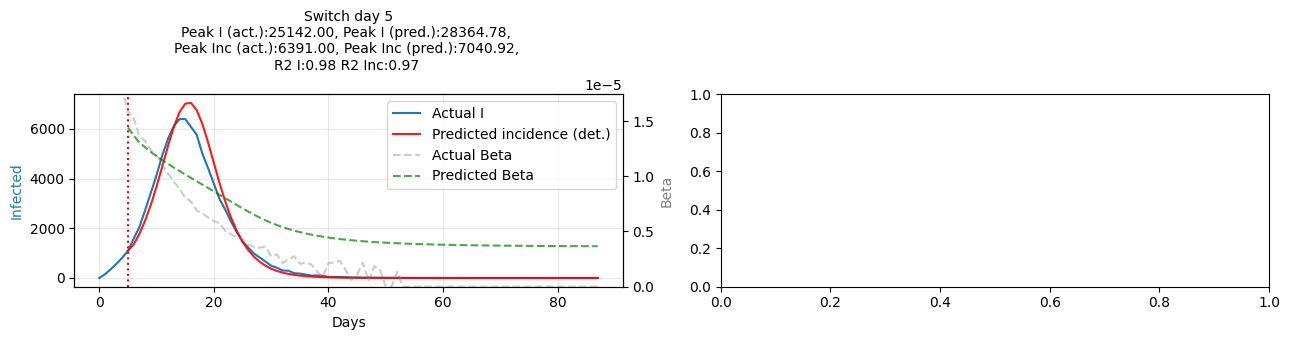

In [19]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[5000::10][:1], on_incidence=True,
              idx_s=4, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_10')

In [23]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.005,
             suff_m='ba100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [29]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.0075,
             suff_m='ba100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [28]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.01,
             suff_m='ba100k', suff='_inc_01')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [25]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.0125,
             suff_m='ba100k', suff='_inc_0125')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [26]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.015,
             suff_m='ba100k', suff='_inc_015')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


## sw

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm


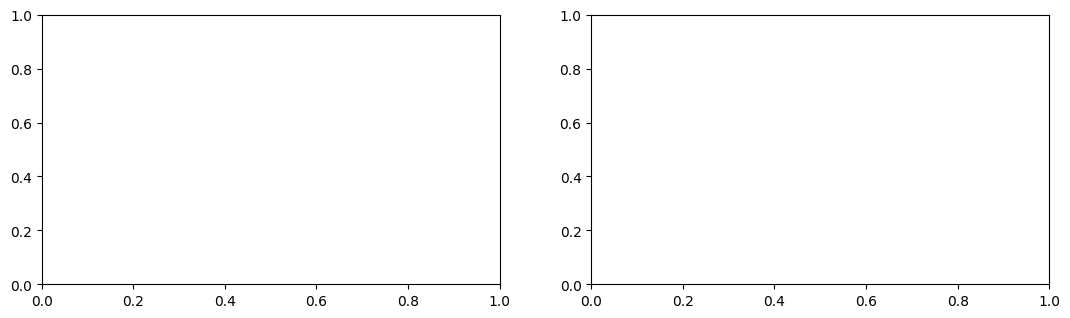

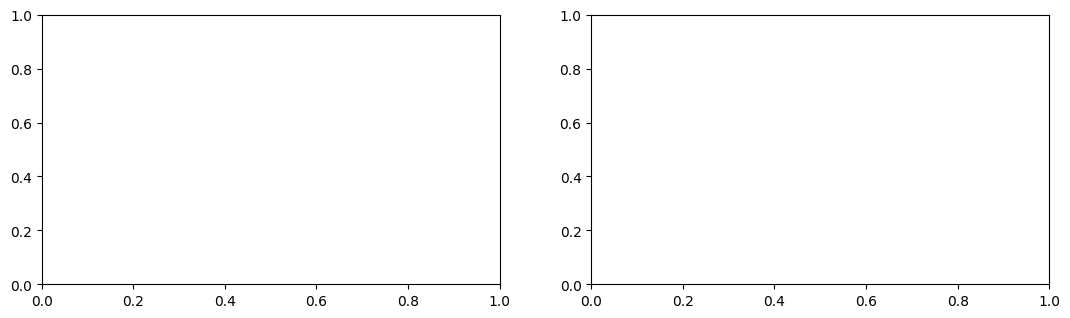

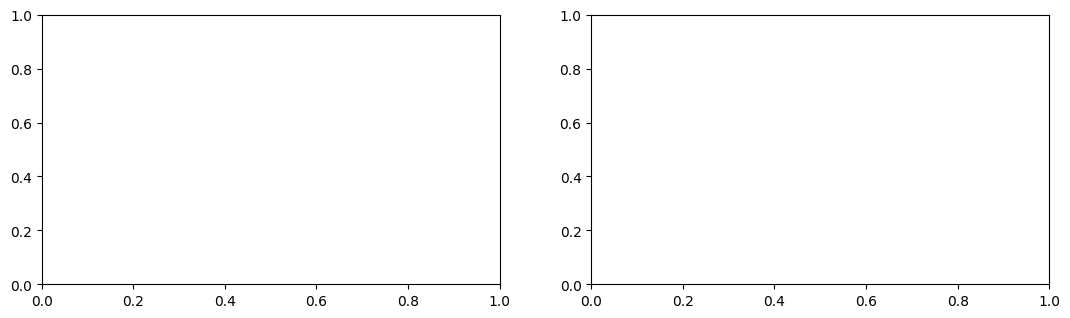

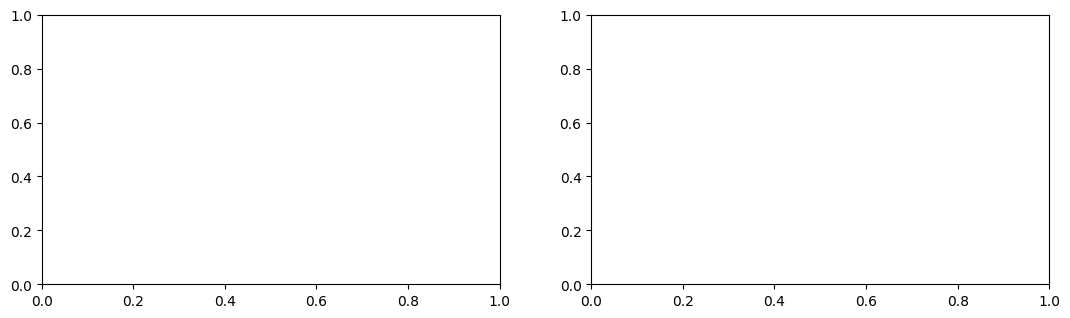

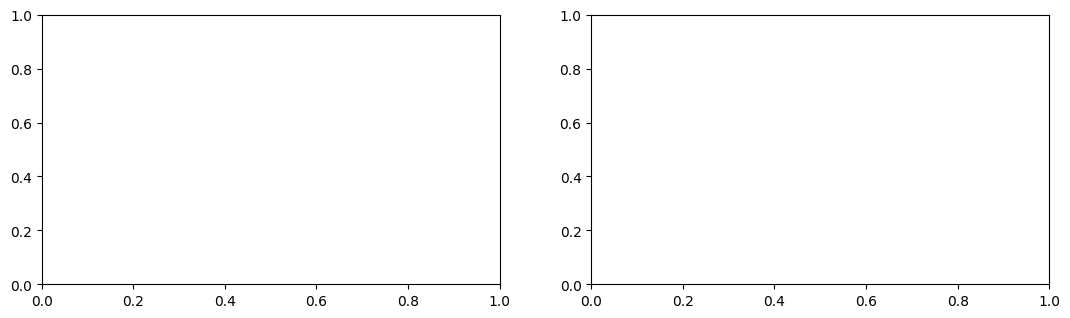

In [22]:
sw = pd.read_csv('test_files.csv').values
k = 22000
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[k:k+1], on_incidence=True,
              idx_s=0, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k')


In [4]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0005,
             suff_m='sw100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [5]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.00075,
             suff_m='sw100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [6]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k', suff='_inc_1')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [7]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0125,
             suff_m='sw100k', suff='_inc_125')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [8]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.015,
             suff_m='sw100k', suff='_inc_15')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
